In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd


In [3]:
# create a dataframe
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# to get the no. of rows and columns
df.shape

(1025, 14)

In [6]:
# to get the detail information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
#check mising values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

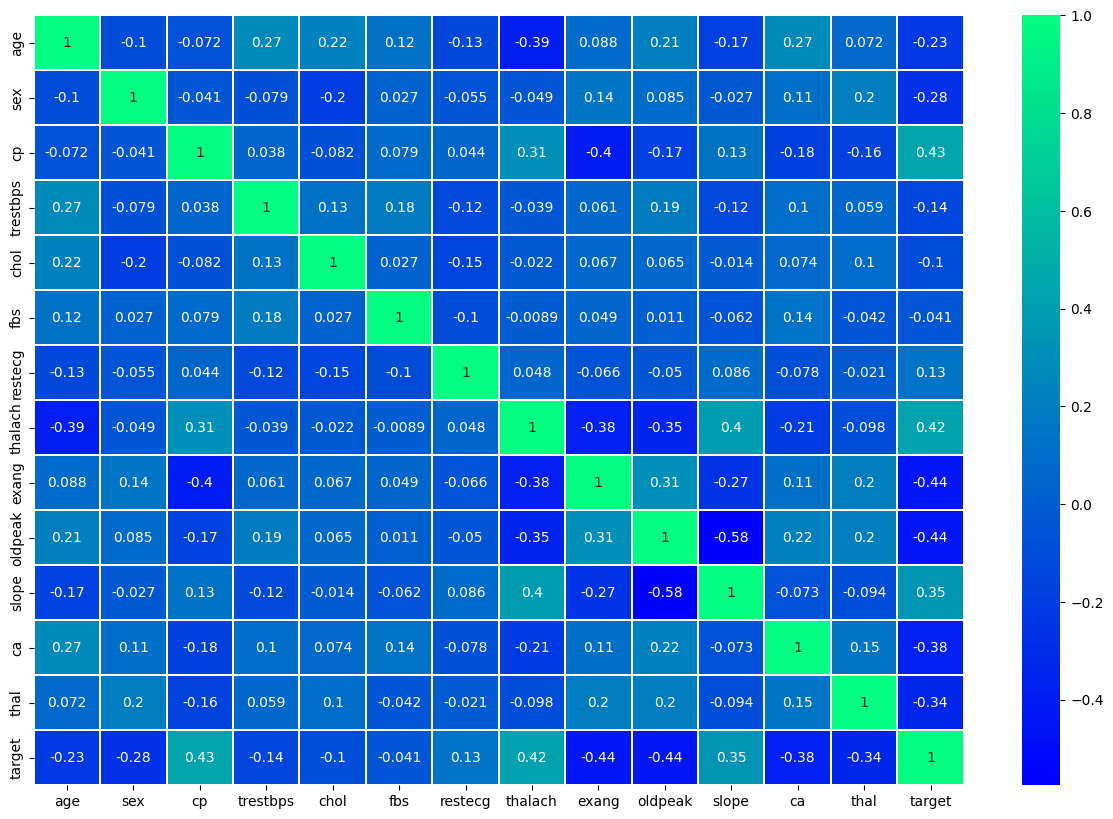

In [16]:
# correlation matrix
#create a heatmap taking correlation matrix
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),linewidth=.01,annot=True,cmap="winter")
plt.show()

 

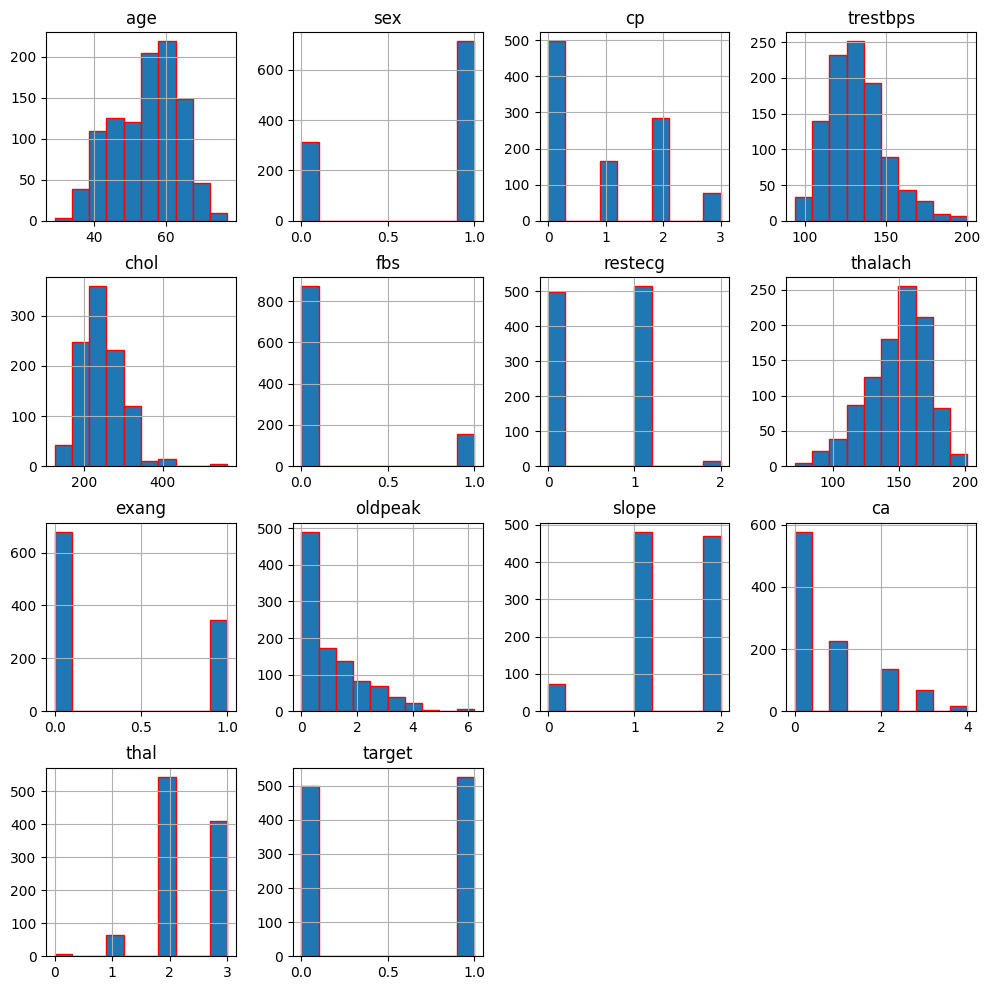

In [18]:
# create a histogram 
df.hist(figsize=(12,12),edgecolor='r')
plt.savefig('featuresplot')

In [19]:
# choose x and y
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [22]:
# split the data set into training and testing data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)


In [23]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,29,1,1,130,204,0,0,202,0,0.0,2,0,2
239,62,0,0,150,244,0,1,154,1,1.4,1,0,2
312,70,1,2,160,269,0,1,112,1,2.9,1,1,3
211,67,1,0,100,299,0,0,125,1,0.9,1,2,2


In [24]:
y_test

527    1
359    1
447    0
31     1
621    0
      ..
668    1
239    0
312    0
211    0
861    0
Name: target, Length: 308, dtype: int64

In [26]:
# create a logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

C:\Users\vikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_prediction=model.predict(x_test)
print(y_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1
 0 1 1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 1 0 0 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0
 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0
 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1
 1 0 1 1 0 0 1 1 1 0 0 1]


In [32]:
# to get the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_prediction))

0.8181818181818182


In [35]:
# to get the accuracy
from sklearn.metrics import confusion_matrix
cn=confusion_matrix(y_test,y_prediction)
print(cn)

[[119  40]
 [ 16 133]]


In [36]:
TP=cn[0][0]
TN=cn[1][1]
FN=cn[1][0]
FP=cn[0][1]


In [40]:
print("Accuracy:",(TP+TN)/TP+TN+FN+FP)
print("Precision",(TP/(TP+FP)))
print("Sensitive",(TP/(TP+FN)))
print("Specificity",(TN/(TN+FP)))

Accuracy: 191.11764705882354
Precision 0.7484276729559748
Sensitive 0.8814814814814815
Specificity 0.7687861271676301


In [41]:
from sklearn.metrics import  classification_report
print(classification_report(y_test,y_prediction))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       159
           1       0.77      0.89      0.83       149

    accuracy                           0.82       308
   macro avg       0.83      0.82      0.82       308
weighted avg       0.83      0.82      0.82       308



In [45]:
import numpy as np

input_data = (62,0,0,124,204,0,1,163,0,0,0,2,0)  # 13 features
arr1 = np.asarray(input_data)
arr2 = arr1.reshape(1, -1)

y_pred = model.predict(arr2)[0]

if y_pred == 1:
    print("The patient has heart disease")
else:
    print("The patient does NOT have heart disease")


The patient has heart disease


C:\Users\vikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
